<div style="background-color: #ffffff; padding: 26px; border: 1px solid #cbd5e1; border-left: 8px solid #ea580c; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">

<!-- JUDUL UTAMA (Paling Besar) -->
<h1 style="color: #0f172a; margin-top: 0; margin-bottom: 18px; font-weight: 800; font-size: 28px; line-height: 1.2;">🏨 Hotel Booking Cancellation: EDA, Modelling & Feature Importance Guide</h1>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6; font-size: 15px;">

Welcome! This notebook provides a complete pipeline for analyzing and predicting hotel booking cancellations. It is designed to help data enthusiasts understand key data drivers and build robust prediction models without data leakage.

</div>

<hr style="border: 0; border-top: 1px solid #e2e8f0; margin-top: 22px; margin-bottom: 22px;">

<!-- KELOMPOK 1: NAVIGASI & HIGHLIGHT (Warna Deep Teal #0f766e) -->
<h2 style="color: #0f766e; margin-top: 15px; margin-bottom: 12px; font-weight: 700; font-size: 20px;">Table of Contents</h2>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

1. **Business Context & Problem Framing**
2. **Exploratory Data Analysis (EDA) & Key Insights**
3. **Data Preprocessing & Anti-Leakage Feature Engineering**
4. **Model Training, Hyperparameter Tuning & Threshold Optimization**

</div>

<h2 style="color: #0f766e; margin-top: 20px; margin-bottom: 12px; font-weight: 700; font-size: 20px;">Key Highlights</h2>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

- **Model:** LightGBM (Tuned)
- **Optimal Threshold:** 0.38 (F1-Score: 0.77 | Recall: 84.5%)
- **Key Insights:** Impact of Lead Time, Parking Requests, and Deposit Types.

</div>

<hr style="border: 0; border-top: 1px solid #e2e8f0; margin-top: 22px; margin-bottom: 22px;">

<!-- KELOMPOK 2: KONTEKS BISNIS & MASALAH (Warna Burnt Orange #c2410c) -->
<h2 style="color: #c2410c; margin-top: 15px; margin-bottom: 12px; font-weight: 700; font-size: 20px;">BACKGROUND</h2>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

A hotel room is a product that cannot be stored for the future; if it remains unsold tonight, the opportunity to generate revenue from that room is lost forever. The challenge lies in the fact that many guests cancel their reservations at the last minute. This creates a dilemma for hotels regarding sales management. Selling too many rooms risks overbooking—where all guests actually show up—while holding back sales risks underbooking, leaving rooms empty due to cancellations. Therefore, hotels need a smart way to predict which guests will actually arrive and which ones will cancel.

👉 This project is designed to be **free from data leakage**, ensuring prediction results remain valid during actual use.

</div>

<h2 style="color: #c2410c; margin-top: 20px; margin-bottom: 12px; font-weight: 700; font-size: 20px;">PROBLEM STATEMENT</h2>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

A high volume of last-minute cancellations places hotels in a capacity dilemma. Implementing an overbooking strategy without accurate forecasting risks turning away guests and damaging the hotel's reputation; conversely, being overly cautious leads to underbooking—where rooms are held for guests who ultimately cancel, resulting in a permanent loss of revenue from other potential customers. Data-driven forecasting models are essential for precisely determining room sales thresholds, ensuring maximum occupancy without compromising customer satisfaction.

</div>

<hr style="border: 0; border-top: 1px solid #e2e8f0; margin-top: 22px; margin-bottom: 22px;">

<!-- KELOMPOK 3: STRATEGI & METRIK EVALUASI (Warna Royal Blue #1d4ed8) -->
<h2 style="color: #1d4ed8; margin-top: 15px; margin-bottom: 12px; font-weight: 700; font-size: 20px;">OBJECTIVE</h2>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

Objectives in this project:

- Conduct Exploratory Data Analysis and data visualization to examine how guest characteristics, reservation patterns, and market trends influence hotel booking cancellations.
- Build a machine learning model capable of predicting whether a guest will cancel their reservation after the booking process is complete, without relying on future data.

</div>

<h2 style="color: #1d4ed8; margin-top: 20px; margin-bottom: 12px; font-weight: 700; font-size: 20px;">BENEFITS</h2>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

- Revenue optimization through safer, data-driven overbooking policies.
- Operational efficiency in staff allocation and hotel logistics.
- Improved marketing strategies by identifying guest segments at high risk of cancellation, enabling the implementation of deposit policies, price adjustments, or more precise room inventory management.

</div>

<h2 style="color: #1d4ed8; margin-top: 20px; margin-bottom: 12px; font-weight: 700; font-size: 20px;">EVALUATION METRICS</h2>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

Evaluation does not rely solely on Accuracy due to data imbalance. The focus is on:

- **Recall**: capturing as many actual cancellations as possible, as a miss (False Negative) is the most costly error.
- **Precision**: ensuring that predicted cancellations are accurate, to prevent excessive overbooking by the hotel.
- **F1-Score**: balancing Recall and Precision.
- **ROC-AUC & PR-AUC**: assessing the model's ability to distinguish between cancellation and non-cancellation classes across various probability thresholds.

</div>

</div>

# DATA PREPARATION & SPLITTING DATA

## 1.1 Data Loading and Sanity Check

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Load dataset, used raw dataset 
df = pd.read_csv('hotel_bookings.csv')

print(f"Initial dataset size: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Identify bookings with no guests
no_guest = (df['adults'] == 0) & (df['children'].fillna(0) == 0) & (df['babies'] == 0)
print(f"Number of booking without a guest: {no_guest.sum():,} rows")

# Clean data by removing bookings with no guests
df = df[~no_guest].copy().reset_index(drop=True)
print(f"Data size after remove booking without a guest: {df.shape[0]:,} rows")

Initial dataset size: 119,390 rows, 32 columns
Number of booking without a guest: 180 rows
Data size after remove booking without a guest: 119,210 rows


## 1.2 Drop Features That Cause Data Leakage

- reservation_status & reservation_status_date: Contain the final status (Check-Out, Canceled, No-Show), which directly reveals the target label `is_canceled` (100% data leakage).
- assigned_room_type: The final room type assigned upon guest check-in.
- booking_changes: The accumulated total of changes made by the guest between the time of booking and arrival.

In [23]:
# List of columns causing data leakage
leakage_cols = [
    'reservation_status',
    'reservation_status_date',
    'assigned_room_type',
    'booking_changes'
]

# Drop leakage column
df.drop(columns=leakage_cols, inplace=True)
print(f"Number of columns remaining after leakage cleaning: {df.shape[1]} columns")

Number of columns remaining after leakage cleaning: 28 columns


## 1.3 Cleaning Data

### Country

In [24]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              478
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
deposit_type                           0
agent                              16280
company                           112442
days_in_waiting_list                   0
customer_type   

In [25]:
df_null_country = df[df['country'].isnull()]
df_null_country['is_canceled'].value_counts()


is_canceled
0    421
1     57
Name: count, dtype: int64

In [26]:
# the number of null value in country are les than 5% of data and is dominated by not cancelled transaction
# we will just drop it
df.dropna(subset=['country'], inplace=True)

### Agent

In [27]:
# Fill null agents with 0 to indicate via direct/corporate booking (based on the documentation)
df["agent"] = df['agent'].fillna(0)
df["agent"] = df['agent'].fillna(0)

Missing values ​​arise from two factors:
1. Direct bookings—reservations made directly with the hotel in person or by phone (without an intermediary agent).
2. Corporate bookings—reservations made by companies with the hotel for their employees.

### Company


In [28]:
# Fill the 'company' column with 0 to indicate 'via agent/mandiri'
df['company'] = df['company'].fillna(0)
df["company"] = df['company'].fillna(0)

"Null" entries for the company are from two factors:
1. Guests who book hotels through third parties (intermediary agents), meaning the company does not pay for or guarantee their bookings (accounting for approximately 85% of these "null" entries);
2. Guests who book independently or arrive as walk-ins.


### Children

In [29]:
# I will assume that these missing values ​​imply not bringing any children, so I will fill them with 0
df['children'] = df['children'].fillna(0)
df['children'] = df['children'].fillna(0)

### "Undefined" Category

In [30]:
# 'Undefined' in the 'meal' column means no meal was ordered, so it is replaced with 'SC' (based on the data provider's documentation)
df['meal'] = df['meal'].replace('Undefined', 'SC', regex = False)

# Since the number of 'Undefined' entries is very small (< 5% of the data), I will simply drop these rows
print(df[df['market_segment'] == 'Undefined']['market_segment'].value_counts())
print(df[df['distribution_channel'] == 'Undefined']['distribution_channel'].value_counts())

df = df[~((df['market_segment'] == 'Undefined') | (df['distribution_channel'] == 'Undefined'))]

market_segment
Undefined    2
Name: count, dtype: int64
distribution_channel
Undefined    5
Name: count, dtype: int64


### ADR
we will check if there is anomaly in adr(minus value and outlier)

In [31]:
df['adr'].describe()

count    118727.000000
mean        102.133353
std          50.389804
min          -6.380000
25%          70.000000
50%          95.000000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

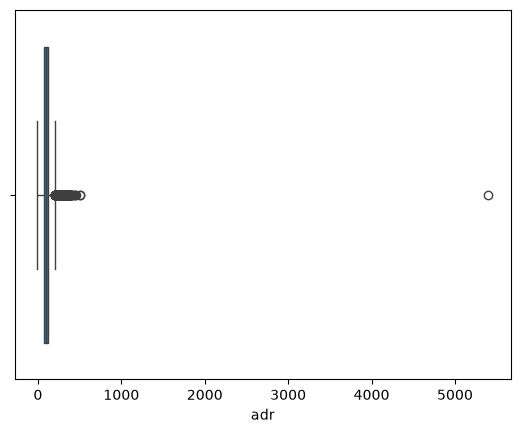

In [32]:
sns.boxplot(x = df['adr'])
plt.show()

In [33]:
df_minus = df[df['adr'] <= 0]

print(df_minus.shape[0])

print(df_minus['is_canceled'].value_counts())

1800
is_canceled
0    1612
1     188
Name: count, dtype: int64


there is 1 outlier with adr above 5000 and minus and  zero value in adr are dominated by not canceled booking. Since total of this anomaly is so small, we can just drop it.

In [34]:
adr_upper_bound = df['adr'].quantile(0.99)
df = df[(df['adr'] > 0) & (df['adr'] < adr_upper_bound)]

## 1.4 Time Series Splitting

Why use Time Series Split instead of Random Split?
Hotel booking behavior is heavily influenced by seasonality and temporal trends. If a random split is used, future data leaks into the training set, causing the model to peek into the future (temporal leakage). With Time Series Split, the data is ordered chronologically from oldest to newest: the initial 80% represents the past (training set), while the most recent 20% represents the future (test set).

In [35]:
# Create a datetime object to retrieve the day of the week
temp_date = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'].astype(str) + '-' +
    df['arrival_date_day_of_month'].astype(str)
)
df['arrival_day_of_week'] = temp_date.dt.dayofweek

# Mapping month text to number
months_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4,
    'May': 5, 'June': 6, 'July': 7, 'August': 8,
    'September': 9, 'October': 10, 'November': 11, 'December': 12
}
df['arrival_date_month_num'] = df['arrival_date_month'].map(months_map)

# Sort the dataset chronologically
df.sort_values(
    by=['arrival_date_year', 'arrival_date_month_num', 'arrival_date_day_of_month'],
    ascending=True,
    inplace=True
)
df.reset_index(drop=True, inplace=True)

df.drop(columns=['arrival_date_month'], inplace=True)
# chronological split
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy().reset_index(drop=True)
test_df = df.iloc[split_index:].copy().reset_index(drop=True)

print("=== TIME SERIES SPLITTING RESULTS ===")
print(f"Train Data (initial 80%) : {len(train_df):,} rows")
print(f" -> Train Time Range: {train_df['arrival_date_year'].min()}-{train_df['arrival_date_month_num'].min()} to {train_df['arrival_date_year'].max()}-{train_df['arrival_date_month_num'].max()}")
print(f"Test Data (final 20%): {len(test_df):,} rows")
print(f" -> Test Time Range : {test_df['arrival_date_year'].min()}-{test_df['arrival_date_month_num'].min()} to {test_df['arrival_date_year'].max()}-{test_df['arrival_date_month_num'].max()}")

=== TIME SERIES SPLITTING RESULTS ===
Train Data (initial 80%) : 92,580 rows
 -> Train Time Range: 2015-1 to 2017-12
Test Data (final 20%): 23,146 rows
 -> Test Time Range : 2017-4 to 2017-8


# EXPLORATORY DATA ANALYSIS

## 2.1 Target Variable Analysis
identify the level of data imbalance (class imbalance).

=== TARGET VARIABLE DISTRIBUTION (train_df) ===
No Cancel (0) : 58,590 orders (63.29%)
Cancel (1) : 33,990 orders (36.71%)


C:\Users\Kent210625\AppData\Local\Temp\ipykernel_21172\3807254178.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='is_canceled', data=train_df, palette=['#2ecc71', '#e74c3c'])


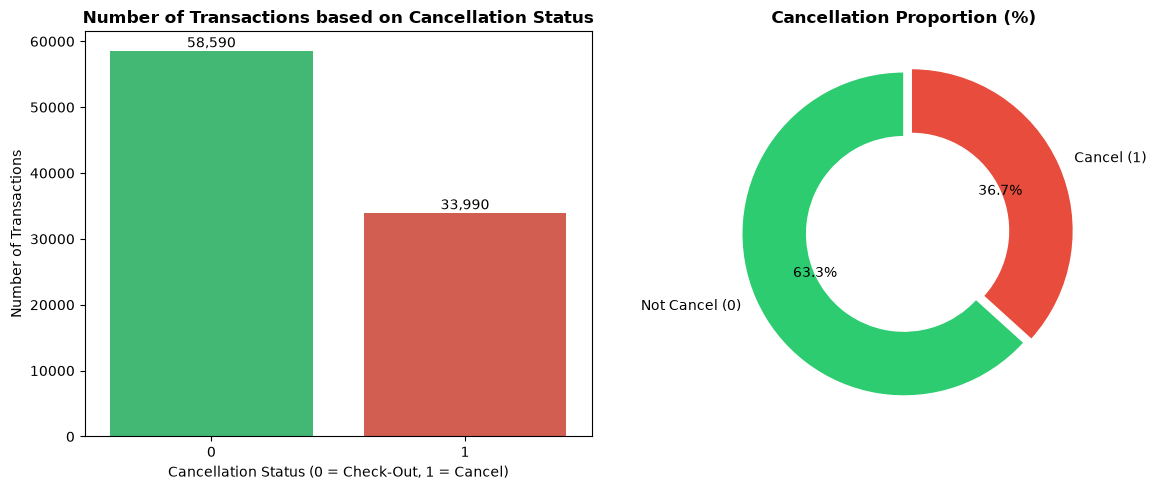

In [36]:
# Calculate frequency distribution and percentages
cancel_counts = train_df['is_canceled'].value_counts()
cancel_percentages = train_df['is_canceled'].value_counts(normalize=True) * 100

print("=== TARGET VARIABLE DISTRIBUTION (train_df) ===")
print(f"No Cancel (0) : {cancel_counts[0]:,} orders ({cancel_percentages[0]:.2f}%)")
print(f"Cancel (1) : {cancel_counts[1]:,} orders ({cancel_percentages[1]:.2f}%)")

# Bar Chart & Donut Chart Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar Plot
sns.countplot(ax=axes[0], x='is_canceled', data=train_df, palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Number of Transactions based on Cancellation Status', fontweight='bold')
axes[0].set_xlabel('Cancellation Status (0 = Check-Out, 1 = Cancel)')
axes[0].set_ylabel('Number of Transactions')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Pie Chart
axes[1].pie(cancel_counts, labels=['Not Cancel (0)', 'Cancel (1)'], autopct='%.1f%%',
            startangle=90, colors=['#2ecc71', '#e74c3c'], explode=(0, 0.05),
            wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1].set_title('Cancellation Proportion (%)', fontweight='bold')

plt.tight_layout()
plt.show()

The data exhibits a mild imbalance, with a ratio of approximately 63% non-cancelled versus 37% cancelled cases. The implication for subsequent modeling is that we must enable class weighting (using `class_weight='balanced'` or `scale_pos_weight`)

## 2.2 Bivariate Analysis of Numerical Variables

C:\Users\Kent210625\AppData\Local\Temp\ipykernel_21172\198815841.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='is_canceled', y=col, data=train_df, palette=['#2ecc71', '#e74c3c'])
C:\Users\Kent210625\AppData\Local\Temp\ipykernel_21172\198815841.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='is_canceled', y=col, data=train_df, palette=['#2ecc71', '#e74c3c'])
C:\Users\Kent210625\AppData\Local\Temp\ipykernel_21172\198815841.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], x='is_canceled'

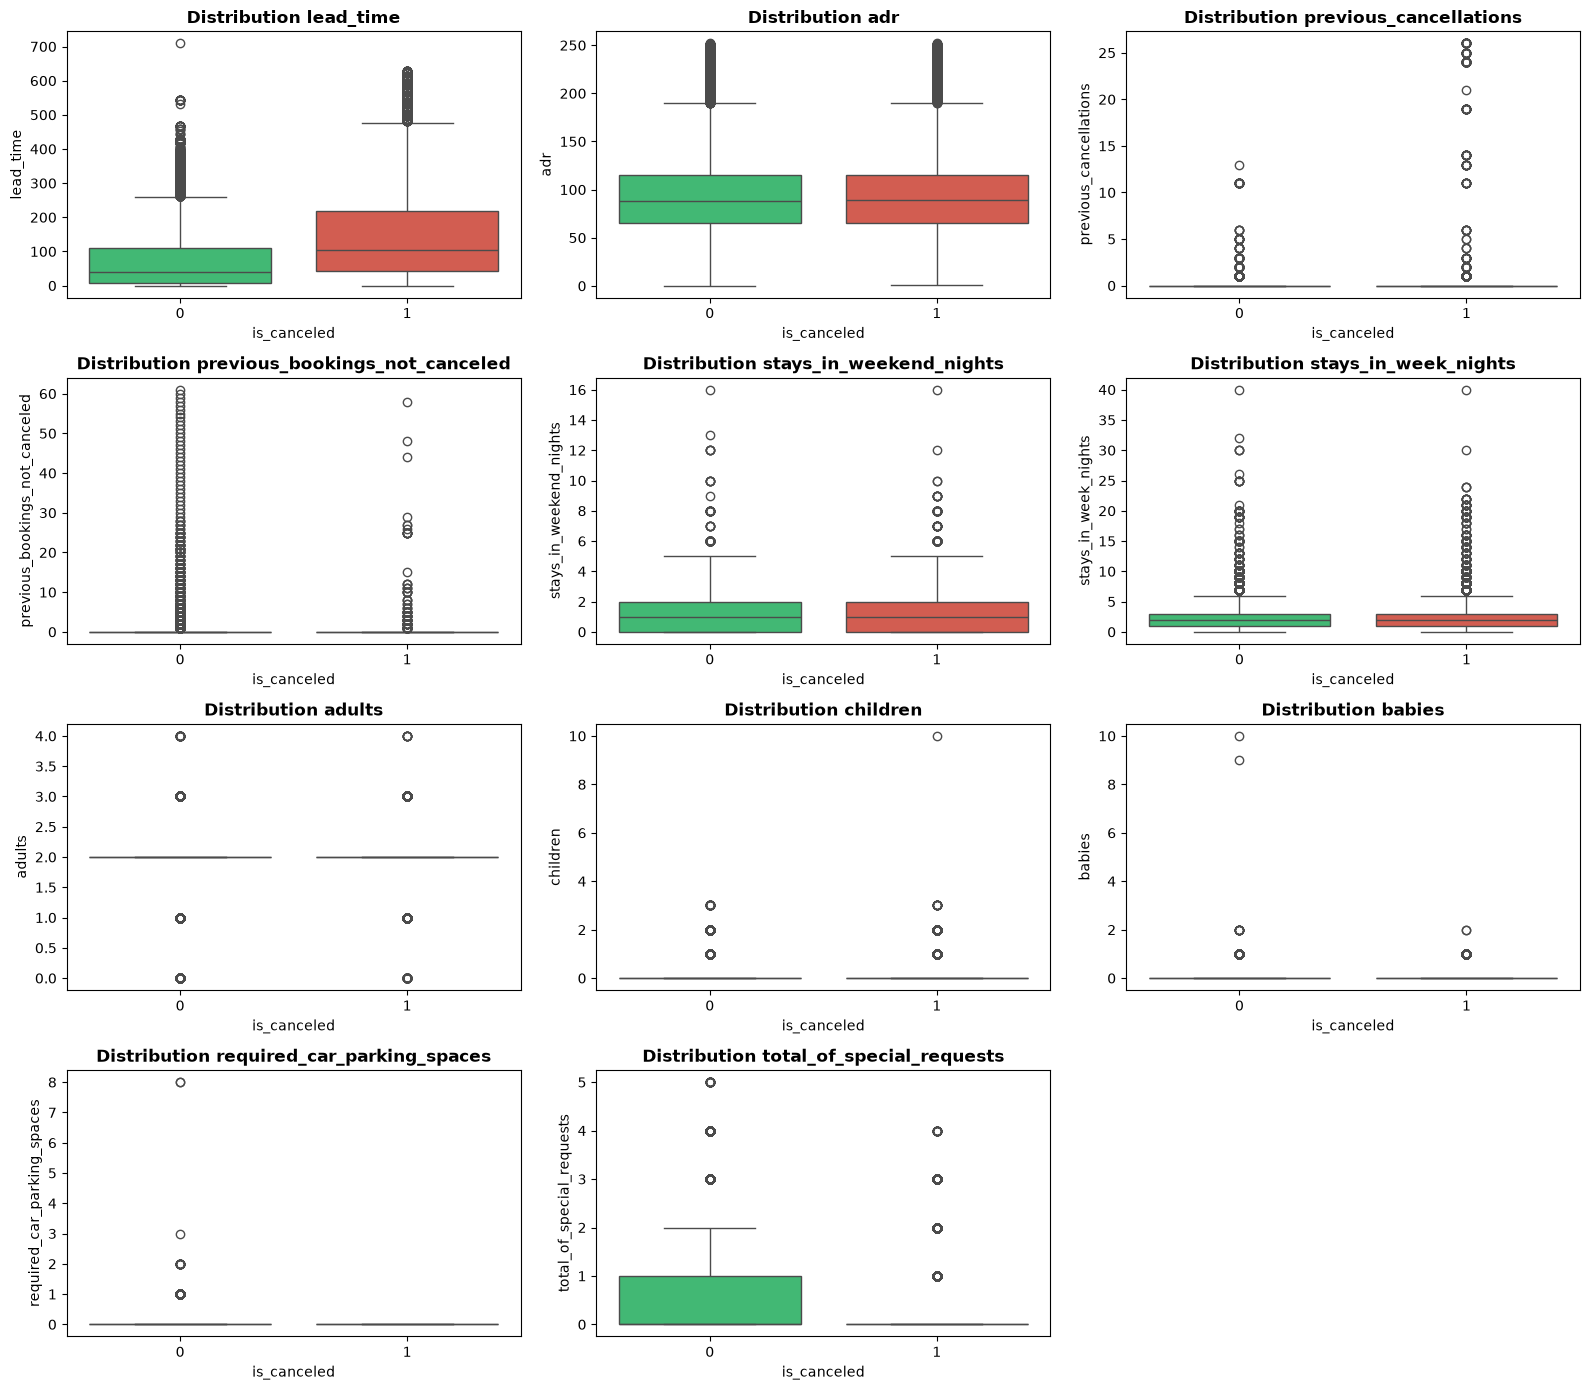

In [37]:
# List of main numerical features
num_cols = [
    'lead_time', 'adr', 'previous_cancellations', 'previous_bookings_not_canceled',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
    'babies', 'required_car_parking_spaces', 'total_of_special_requests'
]

# Boxplot Grid Visualization
fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(ax=axes[i], x='is_canceled', y=col, data=train_df, palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Distribution {col}', fontweight='bold')
    axes[i].set_xlabel('is_canceled')

# Delete the 12th empty subplot
fig.delaxes(axes[11])
plt.tight_layout()
plt.show()

We can get several information from the visualization:
- Lead time shows the most distinct difference. Cancelled reservations tend to have longer lead times.
- The rate of previous cancellations is higher for cancelled reservations, indicating that a history of cancellations is linked to the risk of future cancellations.
- The total number of special requests is higher for non-cancelled reservations, indicating a greater level of guest commitment.
- Some features contain outliers, particularly regarding lead time, ADR, and previous cancellations.

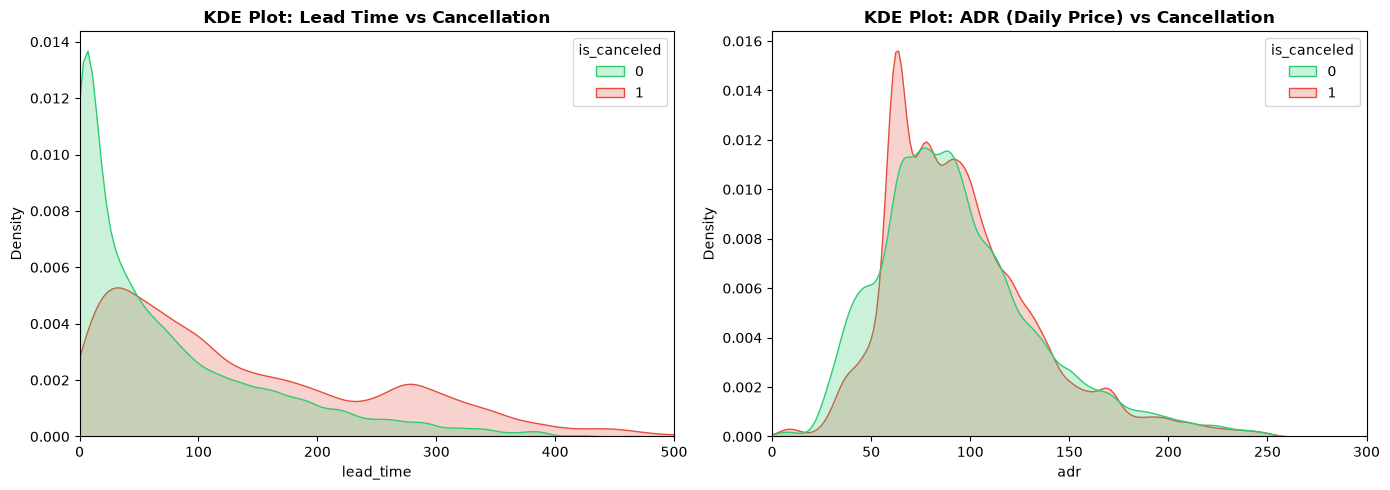

In [38]:
# Lead Time & ADR (Density Plot)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE Lead Time
sns.kdeplot(ax=axes[0], data=train_df, x='lead_time', hue='is_canceled', common_norm=False, fill=True, palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('KDE Plot: Lead Time vs Cancellation', fontweight='bold')
axes[0].set_xlim(0, 500)

# KDE ADR
sns.kdeplot(ax=axes[1], data=train_df, x='adr', hue='is_canceled', common_norm=False, fill=True, palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('KDE Plot: ADR (Daily Price) vs Cancellation', fontweight='bold')
axes[1].set_xlim(0, 300)

plt.tight_layout()
plt.show()

In [39]:
# Crosstab for Parking & Cancellation History
print("--- CANCELLATION RATIO BASED ON PARKING REQUEST (%) ---")
print(pd.crosstab(train_df['required_car_parking_spaces'] > 0, train_df['is_canceled'], normalize='index') * 100)

print("\n--- CANCELLATION RATIO BASED ON PAST CANCELLATION HISTORY (%) ---")
print(pd.crosstab(train_df['previous_cancellations'] > 0, train_df['is_canceled'], normalize='index') * 100)

--- CANCELLATION RATIO BASED ON PARKING REQUEST (%) ---
is_canceled                           0          1
required_car_parking_spaces                       
False                         60.798109  39.201891
True                         100.000000   0.000000

--- CANCELLATION RATIO BASED ON PAST CANCELLATION HISTORY (%) ---
is_canceled                     0          1
previous_cancellations                      
False                   67.417110  32.582890
True                     6.034344  93.965656


Some insight that we get from the visualization:
- Guests who book well in advance (high lead time) are significantly more likely to cancel.
- Guests who request a parking spot (required_car_parking_spaces > 0) have a 0% cancellation rate! This is a 100% certain signal of arrival
- Guests who have cancelled a booking in the past (previous_cancellations > 0) have a >90% likelihood of cancelling again.

## 2.3 Bivariate Analysis of Categorical Variables

C:\Users\Kent210625\AppData\Local\Temp\ipykernel_21172\325249291.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=col, y='is_canceled', data=cat_summary, palette='Reds_r')
C:\Users\Kent210625\AppData\Local\Temp\ipykernel_21172\325249291.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=col, y='is_canceled', data=cat_summary, palette='Reds_r')
C:\Users\Kent210625\AppData\Local\Temp\ipykernel_21172\325249291.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[i], x=col, y='is_canceled', data=cat_summ

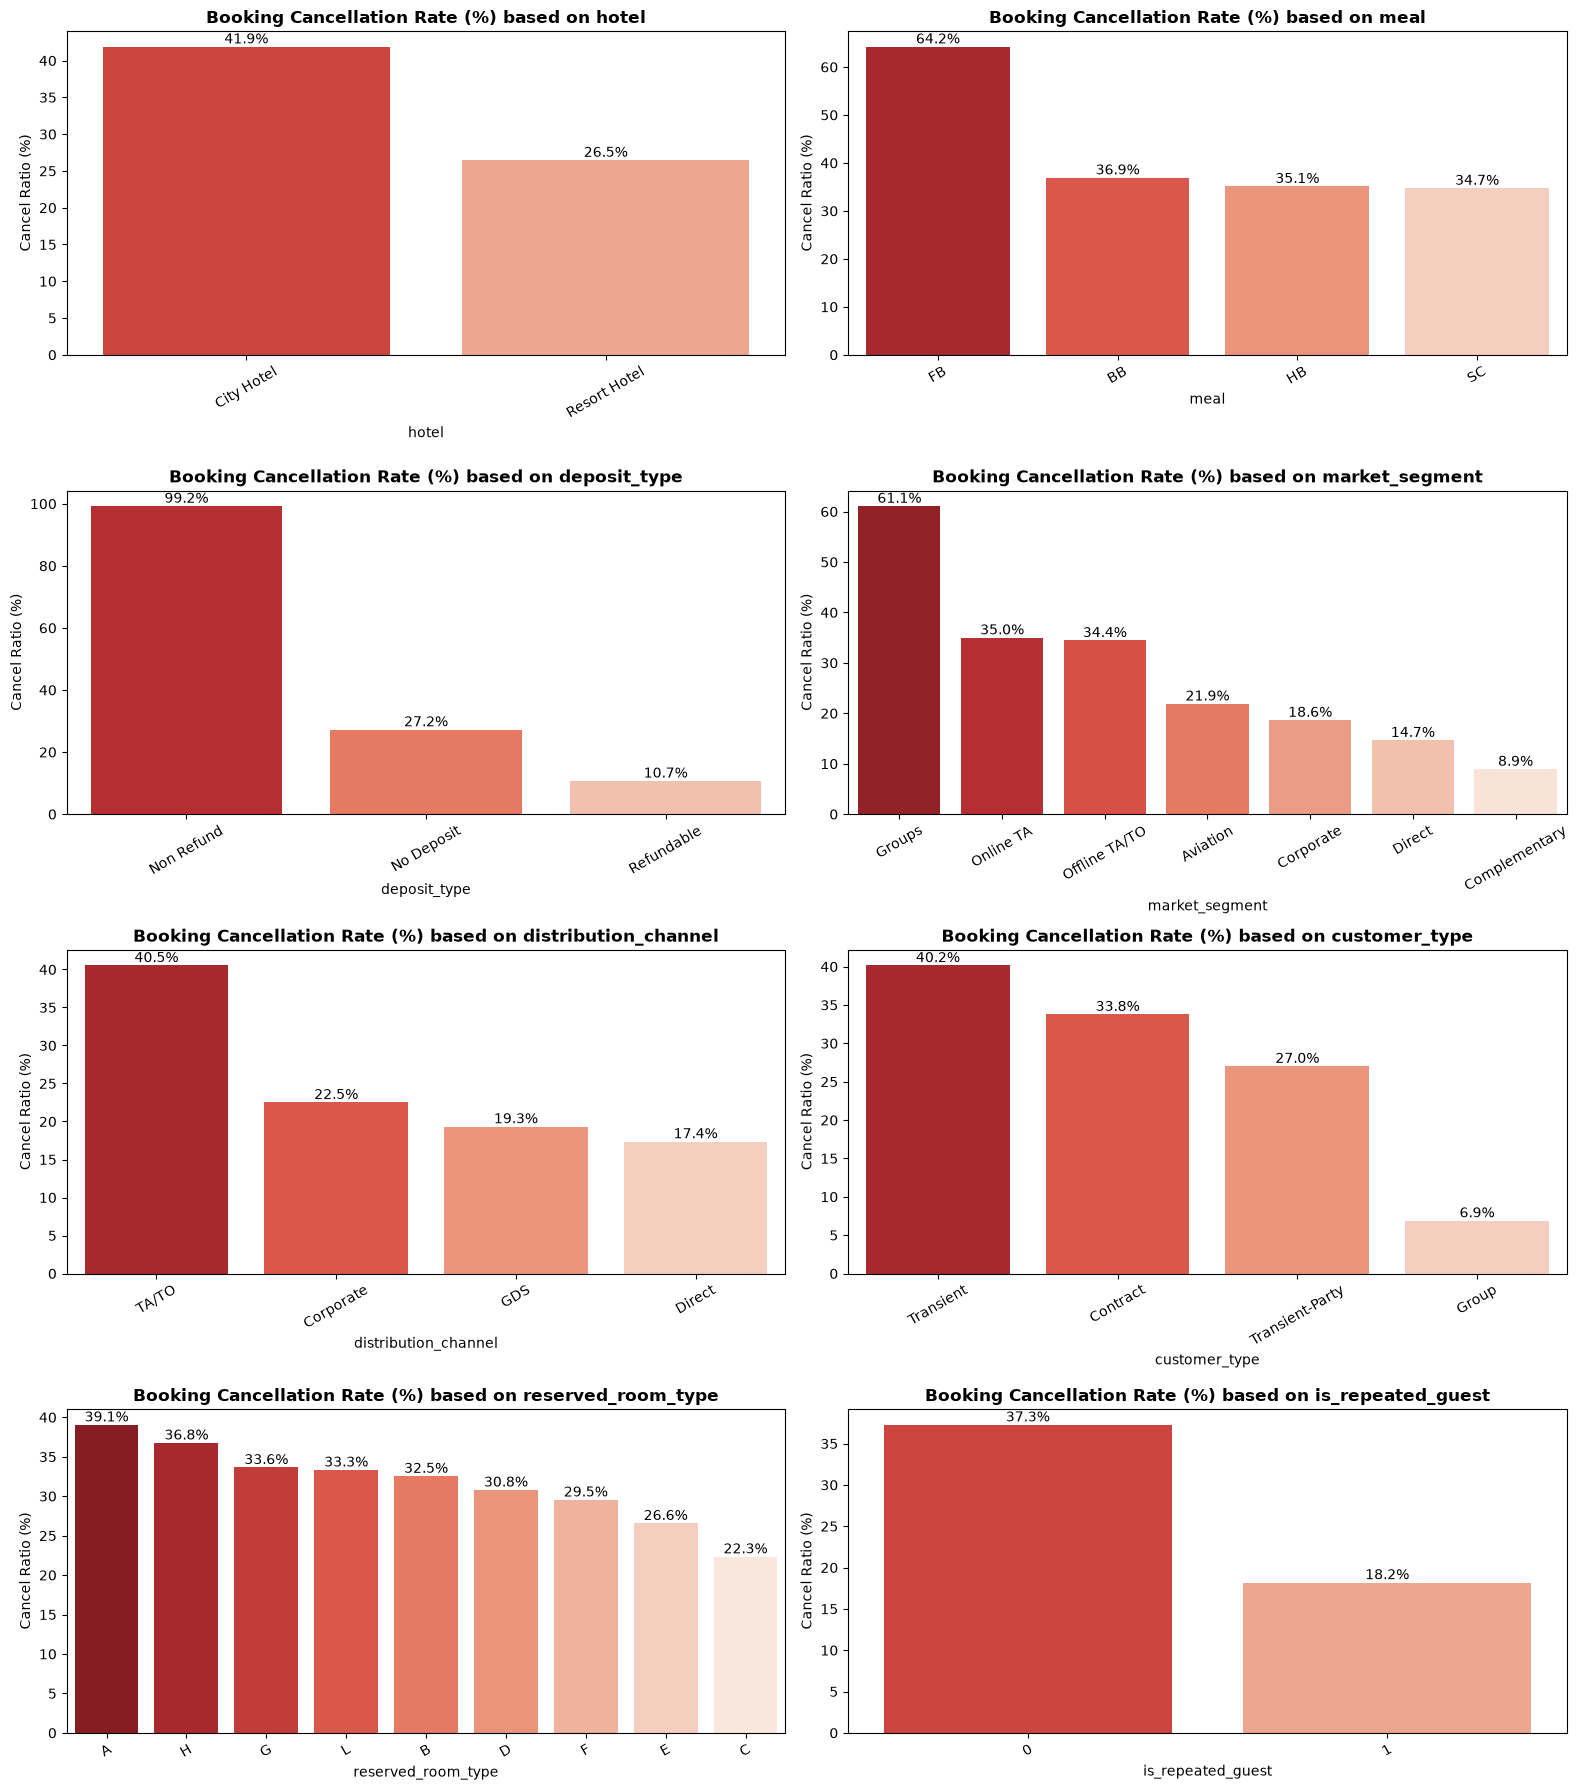

In [40]:
cat_cols = ['hotel', 'meal', 'deposit_type', 'market_segment', 'distribution_channel', 'customer_type', 'reserved_room_type', 'is_repeated_guest']

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Calculate percent void per category
    cat_summary = train_df.groupby(col)['is_canceled'].mean().reset_index()
    cat_summary['is_canceled'] = cat_summary['is_canceled'] * 100
    cat_summary = cat_summary.sort_values(by='is_canceled', ascending=False)

    sns.barplot(ax=axes[i], x=col, y='is_canceled', data=cat_summary, palette='Reds_r')
    axes[i].set_title(f'Booking Cancellation Rate (%) based on {col}', fontweight='bold')
    axes[i].set_ylabel('Cancel Ratio (%)')
    axes[i].tick_params(axis='x', rotation=30)

    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

- City Hotels have a higher cancellation rate (41.9%) compared to Resort Hotels (26.5%).
- non-refundable reservations are almost entirely cancelled (99.3%), whereas refundable ones have the lowest cancellation rate (10.7%).
- the Groups segment and TA/TO channels exhibit relatively high cancellation rates compared to other segments or channels.
- Transient guests have the highest cancellation rate (40.2%), while Groups have the lowest (7.1%).
- Repeat guests cancel reservations far less frequently (18.2%) than new guests (37.3%).


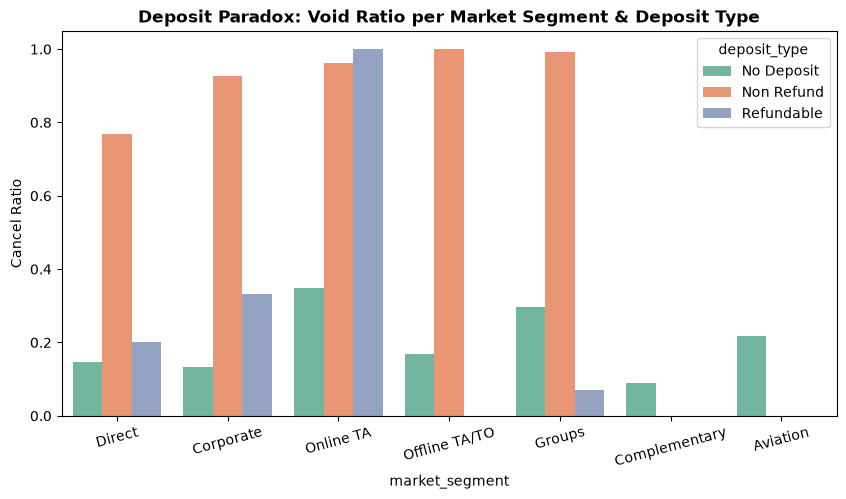

In [41]:
# Non-Refund Paradox Analysis (there is a visa fraud based on the documentation)
plt.figure(figsize=(10, 5))
sns.barplot(data=train_df, x='market_segment', y='is_canceled', hue='deposit_type', palette='Set2', errorbar=None)
plt.title('Deposit Paradox: Void Ratio per Market Segment & Deposit Type', fontweight='bold')
plt.ylabel('Cancel Ratio')
plt.xticks(rotation=15)
plt.show()

Non-refundable deposits show a cancellation rate approaching 100% in the TA/TO and Groups segments. This confirms indications of suspected visa fraud (fake bookings made to meet requirements for overseas visas).

## 2.4 Geospatial and Seasonal Analysis

In [42]:
# GEOSPATIAL ANALYSIS (Choropleth Map)
country_stats = train_df.groupby('country').agg(
    total_bookings=('is_canceled', 'count'),
    cancel_rate=('is_canceled', 'mean')
).reset_index()

# Filter countries with a minimum of 30 orders for stable statistics
country_stats_filtered = country_stats[country_stats['total_bookings'] >= 30].copy()
country_stats_filtered['cancel_rate_pct'] = country_stats_filtered['cancel_rate'] * 100

fig_map = px.choropleth(
    country_stats_filtered,
    locations="country",
    color="cancel_rate_pct",
    hover_name="country",
    hover_data=["total_bookings"],
    color_continuous_scale="Reds",
    title="Geographic Map: Hotel Cancellation Ratio per Guest Country of Origin (%)"
)
fig_map.show()

Portugal (PRT), as the local country, has the highest cancellation rate (>50%), whereas Western European countries such as Germany (DEU), France (FRA), and the UK (GBR) have significantly lower cancellation ratios (<20%).

In [43]:
# SEASONAL TREND ANALYSIS (Monthly Trend)
monthly_trend = train_df.groupby(['arrival_date_year', 'arrival_date_month_num', 'hotel'])['is_canceled'].agg(['count', 'mean']).reset_index()
monthly_trend['date_str'] = monthly_trend['arrival_date_year'].astype(str) + '-' + monthly_trend['arrival_date_month_num'].astype(str).str.zfill(2)
monthly_trend['cancel_rate_pct'] = monthly_trend['mean'] * 100

fig_line = px.line(
    monthly_trend,
    x='date_str',
    y='cancel_rate_pct',
    color='hotel',
    markers=True,
    title='Seasonal Trends: Monthly Cancellation Ratio Fluctuations (2015 - 2017)',
    labels={'date_str': 'Year-Month', 'cancel_rate_pct': 'Cancel Rate (%)'}
)
fig_line.show()

City Hotels exhibit a fairly distinct seasonal pattern. Cancellation rates tend to rise during the July–October period, whereas November–January sees relatively lower cancellation rates.
Resort Hotels show a more stable pattern, though cancellations tend to increase in July–August and decrease in November–January.
Both hotel types have an uptick in cancellation rates mid-year (coinciding with the European summer holiday season), while the period spanning the end of the year and the start of the new year (November–January) tends to see lower cancellation rates.

## 2.5 Multivariate Correlation
Analysis the correlations between all numerical variables in `train_df`.

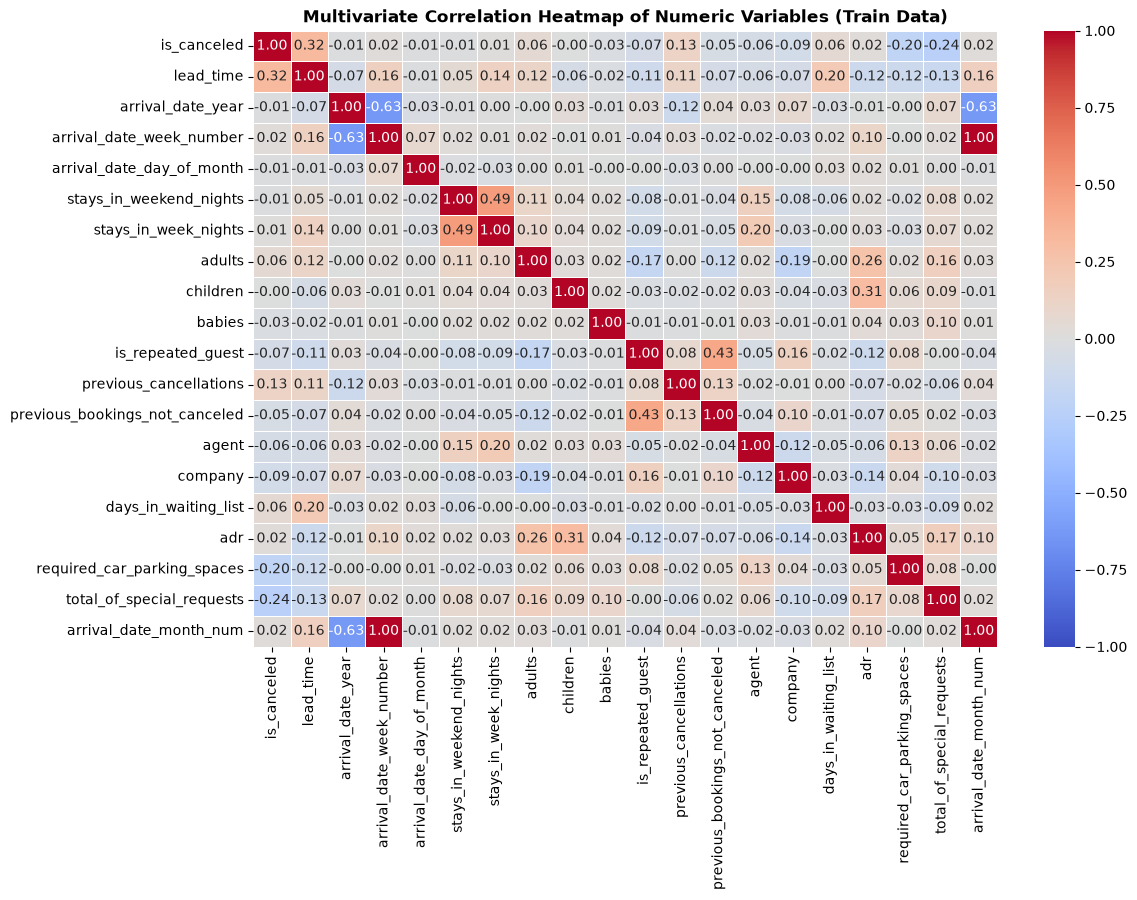

=== CORRELATION OF NUMERIC FEATURES WITH IS_CANCELED ===
is_canceled                       1.000000
lead_time                         0.319461
previous_cancellations            0.128298
days_in_waiting_list              0.062405
adults                            0.055622
arrival_date_month_num            0.022205
arrival_date_week_number          0.019883
adr                               0.015842
stays_in_week_nights              0.011622
children                         -0.004848
arrival_date_day_of_month        -0.009908
arrival_date_year                -0.011633
stays_in_weekend_nights          -0.013430
babies                           -0.029983
previous_bookings_not_canceled   -0.052948
agent                            -0.060814
is_repeated_guest                -0.066867
company                          -0.085647
required_car_parking_spaces      -0.196116
total_of_special_requests        -0.241759
Name: is_canceled, dtype: float64


In [44]:
# Select numeric columns
numeric_df = train_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Multivariate Correlation Heatmap of Numeric Variables (Train Data)', fontweight='bold')
plt.show()

# Correlation ranking with respect to is_canceled
print("=== CORRELATION OF NUMERIC FEATURES WITH IS_CANCELED ===")
print(correlation_matrix['is_canceled'].sort_values(ascending=False))

The numerical features with the highest positive correlation with `is_canceled` are `lead_time` and `previous_cancellations`, whereas `required_car_parking_spaces` and `total_of_special_requests` show a strong negative correlation (the more requests or parking spaces required, the lower the likelihood of cancellation).

## 2.6 Customer History Analysis

In [45]:
print(train_df.groupby('is_canceled')['previous_cancellations'].mean())

is_canceled
0    0.014661
1    0.267755
Name: previous_cancellations, dtype: float64


In [46]:
# View current cancellation percentages based on past cancellation history
print(pd.crosstab(train_df['previous_cancellations'] > 0, train_df['is_canceled'], normalize='index') * 100)

is_canceled                     0          1
previous_cancellations                      
False                   67.417110  32.582890
True                     6.034344  93.965656


Crosstab analysis shows that more than 90% of guests who have previously cancelled a booking will cancel their current booking as well. Based on this insight, we can develop a new feature to simplify the process.

In [47]:
train_df[(train_df['previous_bookings_not_canceled'] > 0) & (train_df['is_repeated_guest'] == 0)].shape[0]

469

There is an anomaly in the data where guests who did not cancel their bookings are not recorded as repeat guests. Therefore, a new feature is needed to indicate that a guest has previously visited the hotel.

## 2.7 Days in Waiting List Analysis

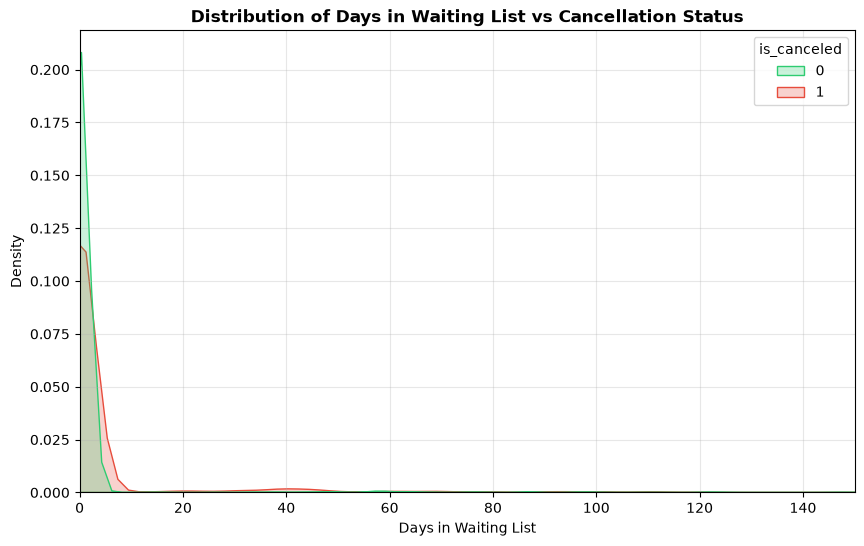

In [48]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=train_df, x='days_in_waiting_list', hue='is_canceled', fill=True, common_norm=False, palette=['#2ecc71', '#e74c3c'])
plt.title('Distribution of Days in Waiting List vs Cancellation Status', fontweight='bold')
plt.xlabel('Days in Waiting List')
plt.ylabel('Density')
plt.xlim(0, 150)
plt.grid(alpha=0.3)
plt.show()

There is no clear pattern regarding the influence of "days in waiting list" on booking cancellations, so we can drop this feature.

In [49]:
for x in [train_df, test_df]:
    x.drop(columns=['days_in_waiting_list'], inplace=True)

<div style="background-color: #ffffff; padding: 22px; border: 1px solid #cbd5e1; border-left: 6px solid #c2410c; border-radius: 8px; margin-bottom: 25px; box-shadow: 0 1px 3px rgba(0,0,0,0.05);">

<h2 style="color: #0f172a; margin-top: 0; margin-bottom: 15px; font-weight: 800;">CONCLUSION</h2>

<h3 style="color: #0f766e; margin-top: 15px; margin-bottom: 12px; font-weight: 700;">Analysis Insights</h3>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

- A long lead time (the interval between booking and arrival) significantly increases the risk of cancellation compared to short-notice bookings.
- Guests with a history of past cancellations have a greater than 90% probability of cancelling their current booking as well.
- Bookings that include requests for vehicle parking or multiple special requests show a very high arrival rate, with a cancellation ratio approaching zero.
- An anomaly exists where non-refundable deposit bookings made via travel agencies or groups show a cancellation rate of nearly 100%, indicating the practice of making fictitious bookings to manipulate visa application requirements.

</div>

<h3 style="color: #c2410c; margin-top: 20px; margin-bottom: 12px; font-weight: 700;">Business Recommendations</h3>

<div style="color: #0f172a; font-weight: 500; line-height: 1.6;">

- Enforce stricter deposit policies or offer special rates with guaranteed arrival for guests booking well in advance.
- Automatically implement safe and calculated overbooking strategies within the system for rooms booked by accounts with a history of cancellations.
- Apply much stricter document and payment verification processes for overseas travel agents to block fictitious reservations that disrupt room inventory management.
- Prioritize room guarantees for guests who reserve parking or submit special requests, in order to maintain service quality for potentially highly loyal customers.

</div>

</div>

**Let's move on to the modeling stage. You can open the file "modeling.ipynb"**

In [50]:
## save preprocessed data to local computer and use this saved data in the modelling section
train_df.to_csv('train_df.csv')
test_df.to_csv('test_df.csv')